/tmp/ipykernel_11058/2160078493.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "time": pd.date_range("2024-01-01", periods=n, freq="H"),


MAE: 2.649010207764014


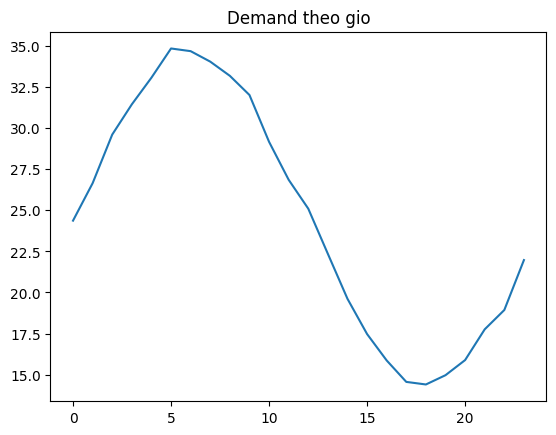

/tmp/ipykernel_11058/2160078493.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone = data.groupby("zone")["demand"].mean()


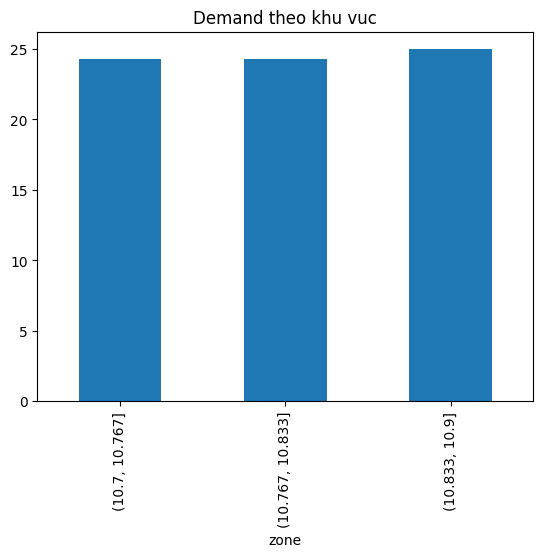

In [28]:
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

np.random.seed(42)

n = 3000

data = pd.DataFrame({
    "time": pd.date_range("2024-01-01", periods=n, freq="H"),
    "lat": np.random.uniform(10.7, 10.9, n),
    "lon": np.random.uniform(106.6, 106.8, n)
})

data["hour"] = data["time"].dt.hour
data["demand"] = 20 + 10*np.sin(data["hour"]/24*2*np.pi) + np.random.randint(0,10,n)

X = data[["lat","lon","hour"]]
y = data["demand"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))

m = folium.Map(location=[10.8,106.7], zoom_start=11)

sample = data.sample(200)

for _, r in sample.iterrows():
    folium.CircleMarker([r["lat"],r["lon"]], radius=r["demand"]/10).add_to(m)

hourly = data.groupby("hour")["demand"].mean()
plt.plot(hourly)
plt.title("Demand theo gio")
plt.show()

data["zone"] = pd.cut(data["lat"], 3)
zone = data.groupby("zone")["demand"].mean()
zone.plot(kind="bar")
plt.title("Demand theo khu vuc")
plt.show()

m

**Nhận xét:**

Nhu cầu dịch vụ thay đổi theo thời gian, thường cao hơn vào một số khung giờ trong ngày.
Ngoài ra, nhu cầu cũng khác nhau giữa các khu vực, có nơi tập trung cao hơn.

Điều này cho thấy cần phân bổ tài xế hoặc nguồn lực nhiều hơn vào các khu vực và thời điểm có nhu cầu cao,
giúp giảm thời gian chờ và nâng cao hiệu quả phục vụ.